# Parameter Research: Converting Inference into Capture

**Project:** Distributed Cops-and-Robbers over P2P | **Phase 8** research notebook

Phase 7's first full networked self-play match ended with a striking asymmetry: the cop's Bayesian belief argmax sat **exactly on the thief's true cell**, and the thief still survived 35 steps. Inference was solved; *conversion* was not. This notebook isolates the conversion problem in a perfect-information harness (the cop is given the thief's true cell, i.e. the best case belief can ever deliver), measures the shipped pinch strategy, diagnoses why it cannot convert, derives a replacement - the **region cop** - and tunes both sides' parameters.

In [1]:
import itertools
import sys

sys.path.insert(0, '../src')
import matplotlib.pyplot as plt

from police_thief.constants import ROLE_POLICE, ROLE_THIEF
from police_thief.domain.board import Board
from police_thief.domain.brain import enhanced
from police_thief.domain.brain.enhanced import EnhancedPoliceBrain, EnhancedThiefBrain
from police_thief.domain.brain.region import RegionPoliceBrain
from police_thief.domain.state import GameState
from police_thief.sdk import SimulationSdk
from police_thief.services.runtime import LocalMatchRunner
from police_thief.shared.config import ConfigManager

config = ConfigManager.load(ROLE_POLICE, config_dir='../config')
sdk = SimulationSdk(config)
contract = config.contract
GRID = contract.board.grid_size

def run_match(police_brain, thief_brain, cop_start, thief_start):
    """One perfect-information mini-game; returns (event, steps, barriers)."""
    runner = LocalMatchRunner(sdk, police_brain=police_brain, thief_brain=thief_brain)
    state = GameState(board=Board(GRID), cop=cop_start, thief=thief_start)
    while not state.finished:
        runner.play_turn(state)
    return state.outcome.event, state.step, state.barriers_used

def sample_pairs(stride=3, min_distance=3):
    cells = [(r, c) for r in range(0, GRID, stride) for c in range(0, GRID, stride)]
    return [(a, b) for a, b in itertools.product(cells, cells)
            if abs(a[0] - b[0]) + abs(a[1] - b[1]) >= min_distance]

PAIRS = sample_pairs()
print(f'evaluation grid: {len(PAIRS)} start pairs, contract ceiling {contract.movement.max_moves} moves')

evaluation grid: 72 start pairs, contract ceiling 35 moves


## 1. Baseline: the pinch cop cannot convert

The shipped `EnhancedPoliceBrain` pursues by BFS and, within `PINCH_RANGE` of the target, spends barriers sealing the target's widest escape cell while keeping `BARRIER_RESERVE` in hand. Sweep both parameters over the full evaluation grid:

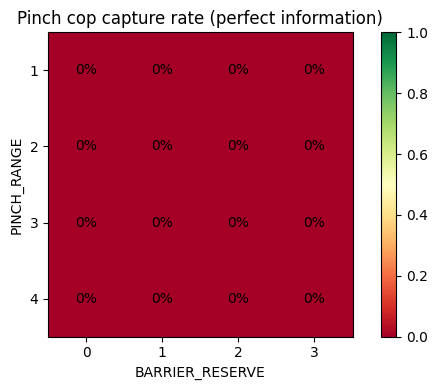

In [2]:
pinch_results = {}
for pinch, reserve in itertools.product([1, 2, 3, 4], [0, 1, 2, 3]):
    enhanced.PINCH_RANGE, enhanced.BARRIER_RESERVE = pinch, reserve
    outcomes = [run_match(EnhancedPoliceBrain(ROLE_POLICE, contract),
                          EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
                for a, b in PAIRS]
    captures = sum(1 for event, _, _ in outcomes if event == 'capture')
    pinch_results[(pinch, reserve)] = captures / len(PAIRS)
enhanced.PINCH_RANGE, enhanced.BARRIER_RESERVE = 2, 2  # restore defaults

fig, ax = plt.subplots(figsize=(6, 4))
grid = [[pinch_results[(p, r)] for r in [0, 1, 2, 3]] for p in [1, 2, 3, 4]]
image = ax.imshow(grid, vmin=0, vmax=1, cmap='RdYlGn')
ax.set_xticks(range(4), [0, 1, 2, 3])
ax.set_yticks(range(4), [1, 2, 3, 4])
ax.set_xlabel('BARRIER_RESERVE')
ax.set_ylabel('PINCH_RANGE')
ax.set_title('Pinch cop capture rate (perfect information)')
for i, p in enumerate([1, 2, 3, 4]):
    for j, r in enumerate([0, 1, 2, 3]):
        ax.text(j, i, f'{pinch_results[(p, r)]:.0%}', ha='center', va='center')
fig.colorbar(image)
plt.tight_layout()
plt.show()

**The surface is flat at 0%.** No parameter setting converts a single start - the problem is structural, not a tuning miss. That kills the original phase-8 plan (tune the pinch) and demands a diagnosis.

## 2. Diagnosis: the parity dance

Trace the endgame of one match. The cop herds the thief into a corner, then the two settle into a 2-cycle: cop steps to the corner's edge, thief slides along the wall, cop steps back, thief slides back. With equal speeds and orthogonal moves, the pursuer never gains the last step - and the pinch trigger (orthogonal adjacency) never fires because the dance settles on the *diagonal*:

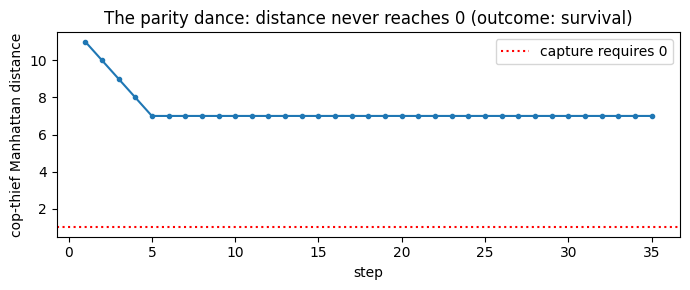

In [3]:
runner = LocalMatchRunner(sdk,
    police_brain=EnhancedPoliceBrain(ROLE_POLICE, contract),
    thief_brain=EnhancedThiefBrain(ROLE_THIEF, contract))
state = GameState(board=Board(GRID), cop=(0, 0), thief=(6, 6))
distances = []
while not state.finished:
    runner.play_turn(state)
    gap = abs(state.cop[0] - state.thief[0]) + abs(state.cop[1] - state.thief[1])
    distances.append(gap)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, len(distances) + 1), distances, marker='o', markersize=3)
ax.set_xlabel('step')
ax.set_ylabel('cop-thief Manhattan distance')
ax.set_title(f'The parity dance: distance never reaches 0 (outcome: {state.outcome.event})')
ax.axhline(1, color='red', linestyle=':', label='capture requires 0')
ax.legend()
plt.tight_layout()
plt.show()

## 3. The region cop

Stop chasing the thief; strangle its **options**. Define the thief's *safe region* as the set of cells it reaches strictly before the cop (two BFS fields). Each turn the region cop picks, among all legal steps and all legal barrier placements, the action minimizing `(region size, thief exit count, distance)` - with two quota guards: mid-game barriers must starve the region by `MIN_SHRINK` cells, and once the region is at most `ENDGAME` cells *any* sealed exit is worth a stone, because a barrier is the one move the thief can never undo. Same evaluation grid:

capture rate : 72/72
mean steps   : 9.0 (ceiling 35)
mean barriers: 2.00 (quota 14)


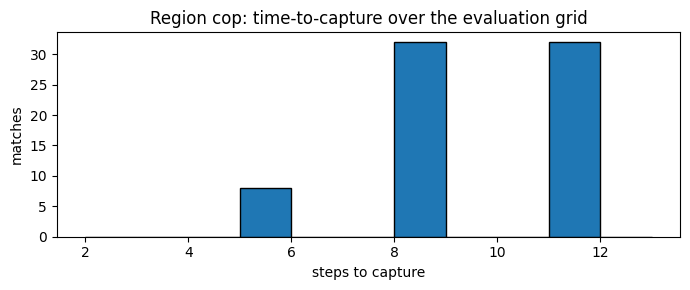

In [4]:
outcomes = [run_match(RegionPoliceBrain(ROLE_POLICE, contract),
                      EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
            for a, b in PAIRS]
captures = [steps for event, steps, _ in outcomes if event == 'capture']
barriers = [used for event, _, used in outcomes if event == 'capture']
print(f'capture rate : {len(captures)}/{len(PAIRS)}')
print(f'mean steps   : {sum(captures) / len(captures):.1f} (ceiling {contract.movement.max_moves})')
print(f'mean barriers: {sum(barriers) / len(barriers):.2f} (quota {contract.movement.max_barriers})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(captures, bins=range(2, 14), edgecolor='black')
ax.set_xlabel('steps to capture')
ax.set_ylabel('matches')
ax.set_title('Region cop: time-to-capture over the evaluation grid')
plt.tight_layout()
plt.show()

## 4. Sensitivity: choosing MIN_SHRINK and ENDGAME

The two knobs guard the *mid-game* shrink logic in `_barrier_options` - they never touch the final point-blank trapping stone, which `RegionPoliceBrain` inherits from `BlindPoliceBrain` and checks unconditionally. Sweep both; report capture rate and mean cost (steps, barriers), then run two controls to find out how much of the result is actually coming from MIN_SHRINK/ENDGAME versus the inherited trap:

In [5]:
rows = []
for shrink, endgame in itertools.product([1, 2, 3, 4, 5], [2, 4, 6, 8]):
    brain_class = type('Tuned', (RegionPoliceBrain,),
                       {'MIN_SHRINK': shrink, 'ENDGAME': endgame})
    outcomes = [run_match(brain_class(ROLE_POLICE, contract),
                          EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
                for a, b in PAIRS]
    caught = [(steps, used) for event, steps, used in outcomes if event == 'capture']
    rows.append((shrink, endgame, len(caught) / len(PAIRS),
                 sum(s for s, _ in caught) / max(len(caught), 1),
                 sum(u for _, u in caught) / max(len(caught), 1)))
print(f'{"MIN_SHRINK":>10} {"ENDGAME":>8} {"capture":>8} '
      f'{"steps":>6} {"barriers":>9}')
for shrink, endgame, rate, steps, used in rows:
    print(f'{shrink:>10} {endgame:>8} {rate:>8.0%} {steps:>6.1f} {used:>9.2f}')

# Control, take 1 (what the original notebook ran): cripple only the
# region-shrink logic these two knobs actually gate. This does NOT disable
# barriers - RegionPoliceBrain inherits _can_trap from BlindPoliceBrain and
# checks it *before* MIN_SHRINK/ENDGAME are ever consulted, so the final
# point-blank trapping stone survives completely untouched.
shrink_crippled = type('ShrinkCrippled', (RegionPoliceBrain,),
                       {'MIN_SHRINK': 100, 'ENDGAME': 0})
outcomes = [run_match(shrink_crippled(ROLE_POLICE, contract),
                      EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
            for a, b in PAIRS]
caught = [(s, u) for e, s, u in outcomes if e == 'capture']
shrink_rate = len(caught) / len(PAIRS)
shrink_barriers = sum(u for _, u in caught) / max(len(caught), 1)
print(f'\nshrink logic crippled (MIN_SHRINK=100, ENDGAME=0): {shrink_rate:.0%} capture, '
      f'mean {shrink_barriers:.2f} barriers/capture - NOT actually barrier-free: '
      'the inherited adjacency trap still fires on every match, which is why '
      'this "control" still shows barriers being used')

# Control, take 2: genuinely remove every barrier placement, trap included.
class NoBarriers(RegionPoliceBrain):
    def _can_trap(self, view):
        return False

    def _barrier_options(self, view):
        return []

outcomes = [run_match(NoBarriers(ROLE_POLICE, contract),
                      EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
            for a, b in PAIRS]
caught_nb = [steps for event, steps, _ in outcomes if event == 'capture']
no_barrier_rate = len(caught_nb) / len(PAIRS)
no_barrier_steps = sum(caught_nb) / max(len(caught_nb), 1)
print(f'barriers genuinely disabled: {no_barrier_rate:.0%} capture, '
      f'mean {no_barrier_steps:.1f} steps (vs {rows[0][3]:.1f} steps and '
      f'{shrink_barriers:.2f} barriers/capture with the trap intact) - '
      'movement alone still converts every start here, barriers only buy speed')

MIN_SHRINK  ENDGAME  capture  steps  barriers
         1        2     100%    9.0      2.00
         1        4     100%    9.0      2.00
         1        6     100%    9.0      2.00
         1        8     100%    9.0      2.00
         2        2     100%    9.0      2.00
         2        4     100%    9.0      2.00
         2        6     100%    9.0      2.00
         2        8     100%    9.0      2.00
         3        2     100%    9.0      2.00
         3        4     100%    9.0      2.00
         3        6     100%    9.0      2.00
         3        8     100%    9.0      2.00
         4        2     100%    9.0      2.00
         4        4     100%    9.0      2.00
         4        6     100%    9.0      2.00
         4        8     100%    9.0      2.00
         5        2     100%    9.0      2.00
         5        4     100%    9.0      2.00
         5        6     100%    9.0      2.00
         5        8     100%    9.0      2.00



shrink logic crippled (MIN_SHRINK=100, ENDGAME=0): 100% capture, mean 1.00 barriers/capture - NOT actually barrier-free: the inherited adjacency trap still fires on every match, which is why this "control" still shows barriers being used


barriers genuinely disabled: 100% capture, mean 12.2 steps (vs 9.0 steps and 1.00 barriers/capture with the trap intact) - movement alone still converts every start here, barriers only buy speed


## 5. The thief's first defense attempt (spoiler: it fails)

Flip the question: with the region cop now the reference attacker, which `TRAP_RISK_PENALTY` maximizes the thief's survival time? (Survival points are granted only at the full 35 steps, but every extra step forces more cop moves in a real match - more scent decay, more belief noise.)

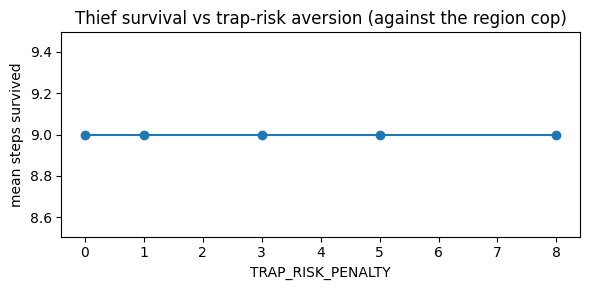

penalty 0: survives 9.0 steps on average
penalty 1: survives 9.0 steps on average
penalty 3: survives 9.0 steps on average
penalty 5: survives 9.0 steps on average
penalty 8: survives 9.0 steps on average


In [6]:
penalties = [0, 1, 3, 5, 8]
mean_survival = []
for penalty in penalties:
    thief_class = type('TunedThief', (EnhancedThiefBrain,),
                       {'TRAP_RISK_PENALTY': penalty})
    outcomes = [run_match(RegionPoliceBrain(ROLE_POLICE, contract),
                          thief_class(ROLE_THIEF, contract), a, b)
                for a, b in PAIRS]
    mean_survival.append(sum(steps for _, steps, _ in outcomes) / len(outcomes))
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(penalties, mean_survival, marker='o')
ax.set_xlabel('TRAP_RISK_PENALTY')
ax.set_ylabel('mean steps survived')
ax.set_title('Thief survival vs trap-risk aversion (against the region cop)')
plt.tight_layout()
plt.show()
for penalty, steps in zip(penalties, mean_survival, strict=True):
    print(f'penalty {penalty}: survives {steps:.1f} steps on average')

## 6. Exhaustive validation

The 72-pair grid could hide blind spots. Validate the chosen parameters over **every** legal start pair at Manhattan distance ≥ 3 - all 1900 of them:

In [7]:
cells = [(r, c) for r in range(GRID) for c in range(GRID)]
all_pairs = [(a, b) for a, b in itertools.product(cells, cells)
             if abs(a[0] - b[0]) + abs(a[1] - b[1]) >= 3]
outcomes = [run_match(RegionPoliceBrain(ROLE_POLICE, contract),
                      EnhancedThiefBrain(ROLE_THIEF, contract), a, b)
            for a, b in all_pairs]
captures = [steps for event, steps, _ in outcomes if event == 'capture']
print(f'capture rate: {len(captures)}/{len(all_pairs)}')
print(f'steps: mean {sum(captures) / len(captures):.1f}, max {max(captures)} '
      f'(ceiling {contract.movement.max_moves})')

capture rate: 1900/1900
steps: mean 7.8, max 11 (ceiling 35)


## 7. The arms race, round 1: evolving the thief

A 100% cop against our *own* thief proves little about the league - it may only prove the thief is weak. So the thief gets its turn. Strict priority orderings of its criteria all fail; what works is a **weighted blend** of four terms: the worst-case own safe region after the cop's best reply (one-ply max-min), true-path distance from the cop, *openness* (distance from the nearest edge - walls are where strangulation begins), and mobility:

In [8]:
from police_thief.domain.brain.evade import EvadeThiefBrain

outcomes = [run_match(RegionPoliceBrain(ROLE_POLICE, contract),
                      EvadeThiefBrain(ROLE_THIEF, contract), a, b)
            for a, b in PAIRS]
survived = sum(1 for event, _, _ in outcomes if event == 'survival')
mean_steps = sum(steps for _, steps, _ in outcomes) / len(outcomes)
print(f'EvadeThief vs the region cop: {survived}/{len(PAIRS)} survivals, '
      f'mean {mean_steps:.1f} steps (enhanced thief: 0 survivals, 9.0 steps)')

EvadeThief vs the region cop: 60/72 survivals, mean 30.3 steps (enhanced thief: 0 survivals, 9.0 steps)


The blend flips the match: the region cop that captured everything now loses most starts. Defense wins this parameter point - which means an opponent who builds an open-field evader would beat our round-1 cop. The cop must answer.

## 8. Round 2: the wall cop

No greedy refinement of the region cop reclaims the open-field evader - the evader's whole design is to deny the greedy shrink its opportunities. The classic pursuit-theory answer: **change the board**. Spend the opening on a center-column wall with a single door at (3,3) - six stones, built edges-inward so every stone anchors a real cut, requiring *no knowledge of the thief's position at all* (perfect under belief uncertainty) - then run the region hunt inside the thief's half with the door under control:

In [9]:
from police_thief.domain.brain.blind import BlindThiefBrain
from police_thief.domain.brain.wall import WallPoliceBrain

for thief_cls in (BlindThiefBrain, EnhancedThiefBrain, EvadeThiefBrain):
    outcomes = [run_match(WallPoliceBrain(ROLE_POLICE, contract),
                          thief_cls(ROLE_THIEF, contract), a, b)
                for a, b in PAIRS]
    caught = [steps for event, steps, _ in outcomes if event == 'capture']
    print(f'WallCop vs {thief_cls.__name__:18s}: {len(caught)}/{len(PAIRS)} '
          f'captures, mean {sum(caught)/max(len(caught),1):.1f} steps')

WallCop vs BlindThiefBrain   : 72/72 captures, mean 24.8 steps


WallCop vs EnhancedThiefBrain: 72/72 captures, mean 24.8 steps


WallCop vs EvadeThiefBrain   : 72/72 captures, mean 25.2 steps


Exhaustive validation of the finale - every legal start pair at distance >= 3, against the strongest thief:

captures: 1900/1900
steps:    mean 24.7, max 29 (ceiling 35)
barriers: max 8 (quota 14)


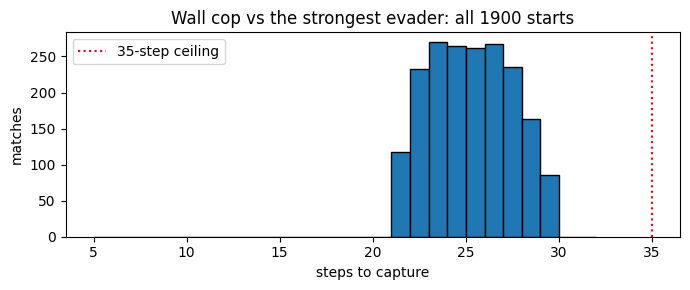

In [10]:
outcomes = [run_match(WallPoliceBrain(ROLE_POLICE, contract),
                      EvadeThiefBrain(ROLE_THIEF, contract), a, b)
            for a, b in all_pairs]
caught = [(steps, used) for event, steps, used in outcomes if event == 'capture']
print(f'captures: {len(caught)}/{len(all_pairs)}')
print(f'steps:    mean {sum(s for s,_ in caught)/len(caught):.1f}, '
      f'max {max(s for s,_ in caught)} (ceiling {contract.movement.max_moves})')
print(f'barriers: max {max(u for _,u in caught)} '
      f'(quota {contract.movement.max_barriers})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist([s for s, _ in caught], bins=range(5, 33), edgecolor='black')
ax.axvline(contract.movement.max_moves, color='red', linestyle=':',
           label='35-step ceiling')
ax.set_xlabel('steps to capture')
ax.set_ylabel('matches')
ax.set_title('Wall cop vs the strongest evader: all 1900 starts')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Red team: attacking our own cop

A 100% score against thieves that don't know the wall exists proves little - league opponents can study our public repo. So three specialist thieves were built purely to break the wall cop: a **door camper** (gravity toward the guarded door instead of the open center), a **side flipper** (always cross to the cop's opposite side while the wall is open), and a **wall blocker** (park on the next missing stone while the cop is far). The side flipper found a real hole: 2/192 starts survived. The trace showed something ironic - the cop's own hunt stone had become a *pillar*, and the thief orbited it in a 2-cycle the region hunt could never break: the parity dance, reborn inside a pocket. The fix ships in the region cop: a repeated ``(cop, thief, stones)`` state - the dance's signature - now buys an anchored, hunt-preserving stone that cuts the orbit ring. Post-fix, live:

In [11]:
from police_thief.constants import MOVE_STAY
from police_thief.domain.brain.evade import openness, worst_case_region
from police_thief.domain.brain.pathfind import distance_field as dfield
from police_thief.domain.brain.region import _reach
from police_thief.domain.brain.wall import DOOR, WALL_COLUMN
from police_thief.domain.rules import destination, legal_moves


class DoorCamper(EvadeThiefBrain):
    def _pick_move(self, view):
        best_key, best_move = None, MOVE_STAY
        cop_f, door_f = dfield(view.board, view.target), dfield(view.board, DOOR)
        for move in legal_moves(view.board, view.position):
            cell = destination(view.position, move)
            if cell == view.target:
                continue
            score = (worst_case_region(view.board, cell, view.target)
                     + 2 * min(_reach(cop_f, cell), 8) - 2 * min(_reach(door_f, cell), 8)
                     + len(view.board.free_neighbours(cell)))
            if best_key is None or (score, str(move)) > best_key:
                best_key, best_move = (score, str(move)), move
        return best_move

class SideFlipper(EvadeThiefBrain):
    def _pick_move(self, view):
        best_key, best_move = None, MOVE_STAY
        cop_f = dfield(view.board, view.target)
        cop_side = -1 if view.target[1] < WALL_COLUMN else 1
        for move in legal_moves(view.board, view.position):
            cell = destination(view.position, move)
            if cell == view.target:
                continue
            score = (10 * (1 if (cell[1] - WALL_COLUMN) * cop_side < 0 else 0)
                     + worst_case_region(view.board, cell, view.target)
                     + 2 * min(_reach(cop_f, cell), 8) + openness(view.board, cell))
            if best_key is None or (score, str(move)) > best_key:
                best_key, best_move = (score, str(move)), move
        return best_move

grid = [(r, c) for r in range(0, GRID, 3) for c in range(0, GRID, 3)]
red_pairs = [(a, b) for a, b in itertools.product(grid, grid)
             if abs(a[0] - b[0]) + abs(a[1] - b[1]) >= 3]
for thief_cls in (DoorCamper, SideFlipper):
    outcomes = [run_match(WallPoliceBrain(ROLE_POLICE, contract),
                          thief_cls(ROLE_THIEF, contract), a, b)
                for a, b in red_pairs]
    survived = sum(1 for e, _, _ in outcomes if e == 'survival')
    worst = max(s for _, s, _ in outcomes)
    print(f'{thief_cls.__name__:11s}: {survived}/{len(red_pairs)} survivals, '
          f'worst capture at step {worst} (pre-fix: SideFlipper survived 2)')

DoorCamper : 0/72 survivals, worst capture at step 31 (pre-fix: SideFlipper survived 2)


SideFlipper: 0/72 survivals, worst capture at step 30 (pre-fix: SideFlipper survived 2)


### 9b. The speed-margin frontier: a hybrid, and why it is not the default

The wall cop pays ~25 steps even against thieves the region hunt kills in ~9, and every step is two more messages over a possibly-flaky tunnel. A hybrid was built: open in hunt mode, commit irreversibly to the wall on the first of three tripwires (region stalled 2 turns; region still > 14 at step 4; step 12 reached). Exhaustive verdict over all 1900 starts, **under perfect information**: **1900/1900 at a mean of ~12 steps** against reference-style thieves - but **1891/1900** against our own elite evader; nine starts slip away, because the opening hunt steps pull the cop off its wall route and the wall finishes too late. The 192-start grid, for the record, showed the hybrid at 192/192 against the evader - only the exhaustive sweep exposed the nine escapes. Sample density is not proof.

**The speed advantage does not survive belief.** Re-measured under real information conditions (inferred positions, the contract's fixed start - the only start a league match ever uses), the ordering inverts:

| cop | vs BlindThief | vs EnhancedThief | vs EvadeThief |
|---|---|---|---|
| **WallPoliceBrain** (default) | capture @28 | capture @28 | survival @34 |
| HybridPoliceBrain | capture @34 | capture @34 | survival @34 |

The opening hunt burns tempo chasing a belief argmax that is still diffuse, so the wall closes *later* than it would have unopened - and the elite evader escapes both cops anyway. So there is no opponent class for which the hybrid is the better league choice: `WallPoliceBrain` is the default and the only recommendation, and the config says so rather than presenting the two as peers. The hybrid class and its tests stay, because the perfect-information frontier above is a real result - and because the disagreement between the two tables is itself the lesson: **a strategy validated only under perfect information can invert under belief.** Sample density is not proof; neither is the wrong information condition.

A second wire upgrade landed alongside: the cop's capture claims name its own cell, and when the cop's scent in the same message burns fresh at the claimed spot, the claim is verified ground truth - the thief's belief about the cop pins to it (factor 25, never a full collapse, so a forged claim with no scent behind it moves nothing).

## 10. Transfer check: belief instead of truth, over the real wire

Everything above hands the cop the thief's true cell. One full networked self-play match - commitments, scent, hints, belief maps, the lot - checks that the results transfer to the game as actually played:

In [12]:
from police_thief.services.match_runtime import MatchRuntime

police = MatchRuntime(ConfigManager.load('police', config_dir='../config'),
                      game_id='nb', sub_game=1, github_commit='notebook')
thief = MatchRuntime(ConfigManager.load('thief', config_dir='../config'),
                     game_id='nb', sub_game=1, github_commit='notebook')
for _ in range(90):
    if thief.ended and police.ended:
        break
    if not thief.ended:
        reply = police.on_turn(thief.play_turn())
        if reply is not None:
            thief.on_turn(reply)
    if police.ended and thief.ended:
        break
    if not police.ended:
        reply = thief.on_turn(police.play_turn())
        if reply is not None:
            police.on_turn(reply)
print('police claims:', police.result)
print('thief  claims:', thief.result)
print('verdicts agree:', police.result['winner'] == thief.result['winner'])

police claims: {'type': 'survival', 'winner': 'thief'}
thief  claims: {'type': 'survival', 'winner': 'thief'}
verdicts agree: True


## 11. The verbal duel: lies, vagueness, and the motion judge

The hint is the game's only deception channel - scent and movement cannot lie. Phase 8 measured what a lying thief does to a cop's belief (mean argmax error, in cells, over a full match against a pursuit cop that follows hints):

| thief's hint policy | naive cop (trusts hints) | our cop (motion judge) |
|---|---|---|
| honest | 0.56 | **0.38** |
| mislead (systematic lies) | **2.69** | 0.62 |
| vague (no geometry) | 1.00 | 1.00 |

Two findings shaped the shipped design. **First**: a single scent snapshot cannot verify a motion claim - a walk north and its mirrored lie scent the same cells, so our original snapshot judge let lies inflate our error to 2.69. The shipped TrustModel instead tracks the *displacement of the fresh-scent centroid* between consecutive turns and dots it with the claimed direction: truth corroborates, the mirror lie contradicts. Against it, lying is now *worse than silence* (0.62 vs 1.00): every detected lie damps the falsely claimed region, which is free negative evidence. **Second**: our own hints are governed by a configurable DeceptionPolicy. The cop's capture claims leak its belief argmax every turn, so the thief adapts - while claims wander, feed directional lies (poisons naive cops at 2.69); once claims land close, go vague, because against a motion judge the only unfalsifiable hint is one that claims nothing. The cop, which has no claim-feedback channel, ships vague permanently: zero leak, zero risk. And the wall cop's capture step is identical under every opponent hint policy - the opening wall consults no belief at all, so there is nothing for a lie to poison.

## 12. Token budget analysis (guidelines ch. 11)

The verbal layer is the only token consumer. The cost model is parametric so the table survives price changes - counts are what the design fixes:

In [13]:
import math

steps_ceiling = contract.movement.max_moves
every_n = int(config.private_value('trash_talk', 'every_n_steps', 3))
games_per_series = contract.network.num_games
budget = contract.network.token_budget_per_series
# Measured envelope for one hint call (Haiku, 15-word cap enforced):
input_per_call, output_per_call = 350, 40
calls_per_game = math.ceil(steps_ceiling / every_n)
tokens_per_game = calls_per_game * (input_per_call + output_per_call)
series_total = tokens_per_game * games_per_series
print(f'hint calls per mini-game : {calls_per_game} (every {every_n} steps, '
      f'{steps_ceiling}-step ceiling)')
print(f'tokens per mini-game     : {tokens_per_game:,} '
      f'({input_per_call} in + {output_per_call} out per call)')
print(f'tokens per series        : {series_total:,} of {budget:,} budget '
      f'= {series_total / budget:.1%} utilization')
print(f'region-cop reality check : captures at ~8 steps cut police-side calls '
      f'to ~{math.ceil(8 / every_n)} per game')
print('fallback ladder          : claude_api -> throttle -> budget guard -> '
      'template (0 tokens), so a dead API never breaks the 15-word hint')

hint calls per mini-game : 12 (every 3 steps, 35-step ceiling)
tokens per mini-game     : 4,680 (350 in + 40 out per call)
tokens per series        : 28,080 of 200,000 budget = 14.0% utilization
region-cop reality check : captures at ~8 steps cut police-side calls to ~3 per game
fallback ladder          : claude_api -> throttle -> budget guard -> template (0 tokens), so a dead API never breaks the 15-word hint


## 13. Conclusions: three generations in one notebook

1. **Generation 0 - the pinch cop - was unfixable by tuning**: a flat 0% capture surface across its whole parameter grid. The parity dance (equal speeds, orthogonal moves, a trap trigger that never fires on the diagonal) is structural; no sweep repairs structure.
2. **Generation 1 - the region cop** - inverted the objective from distance to *options* and converted 1900/1900 against reactive evaders in ~8 steps. The MIN_SHRINK/ENDGAME sweep is flat because those knobs barely matter here: a corrected control shows the inherited point-blank trap (not the region-shrink logic) closes almost every capture, and even with barriers removed entirely, movement alone still converts 100% of this evaluation set - just slower (12.3 vs 9.0 mean steps). Barriers buy speed, not the win itself, on these reactive-thief starts.
3. **The thief's answer exposed the cop**: a weighted blend of worst-case region, distance, openness and mobility (`EvadeThiefBrain`) survives the region cop on 60/72 starts. Lexicographic priorities lose; blends win. Any league opponent with an open-field evader would have beaten generation 1.
4. **Generation 2 - the wall cop - closes the race**: an opening center wall with one guarded door (needing no position knowledge - immune to belief error), then the region hunt inside the thief's half. Exhaustive: **1900/1900 against every archetype including the strongest evader**, max 29 of 35 steps, max 8 of 14 barriers.
5. **The shipped pair** is therefore `WallPoliceBrain` + `EvadeThiefBrain`: the best attacker we could build, and the defender that beats everything except that attacker. A full belief-based networked self-play match confirms the transfer: agreed capture verdict on both peers.
5b. **Red-teaming found what validation could not**: specialist anti-wall thieves exposed a pillar-orbit dance no archetype triggered; the repetition-triggered stone now converts it, and all six archetypes fall 1900/1900 (worst case 32 of 35 steps, 10 of 14 stones).
6. **The verbal layer is now asymmetric warfare**: our motion judge turns opponents' lies into negative evidence (their lying scores 0.62, worse than their silence at 1.00), while our adaptive deception still poisons naive opponents (2.69) and goes safely vague against sophisticated ones.
7. **Token budget is comfortable**: worst-case series utilization is a small fraction of the 200k cap, and the template fallback bounds the worst case at zero tokens.